# Uebung 2, Aufgabe 2

Kurze Beschreibung des Themas: Schwingungen mit multiplen Freiheitsgraden

Freiheitsgrade kommen immer dann hinzu, wenn Koerper hinzukommen oder wenn diese Koerper mehrere, voneinander unabhaengige Bewegungen ausfuehren. Letzteres ist hier der Fall.

Zusaetzlich haben wir:
- ein freies System --> keine Bode-Diagramme, weniger Slider
- ein nichtlineares System --> zwei graphs fuer je eine Koordinate, sprich lineares + nichtlineares Ergebnis
- zusaetzliche Koordinaten --> mehr Slider (was die Tatsache wieder relativiert, dass wir ein freies System haben yeah)

Das wirklich kritische ist bei dieser Aufgabe eine gute Laenge des Stabs zu waehlen, weil in gewissen Konstellationen die Masse heftig schwingen kann, sodass sie nicht zu sehen ist. Versuch das einfach so ungefaehr hinzukriegen, sodass es mindestens in der default Parameter Konfi gut aussieht.

## parameters

In [55]:
from scipy.integrate import odeint
import numpy as np
import matplotlib.pyplot as plt

# phys. Parameter, Default-Werte, die Grenzen fuer die Slider sind auch angegeben
# Slider-Schrittweiten so waehlen, sodass die Slider "stufenlos" sind
g = 9.81    # gravity constant
J_s = 50   # intertia wrt point S --> SLIDER, (10, 100)
m = 10      # mass --> SLIDER, (5, 20)
c = 50       # spring constant --> SLIDER, (10, 100)
s_0 = 2     # unloaded spring length --> SLIDER, (25% der Laenge des Stabs, 50% der Laenge) 
s_R = m*g/c + s_0 # Rechenparameter 

# initial conditions
s_00 = 4        # initial displacement (Achtung: nicht das gleiche wie s_0) --> SLIDER, --> SLIDER, (0, 50% der Laenge)
                # Je nach dem wie lange du den gestaltest, sollten wir die Slidergrenzen danach einrichten. Ansonsten sieht's in der Animation
                # bisschen witzig aus. Default Wert einfach bei 25% der Laenge waehlen.
phi_0 = 30      # initial deflection --> SLIDER, (-30, 30)
s_dot_0 = 0     # initial velocity --> (-20% der Laenge, 20% der Laenge)
phi_dot_0 = 0   # initial angular velocity --> Slider(-2,2)
z_0 = (s_00, phi_0*np.pi/180, s_dot_0, phi_dot_0)

# Zeiteinstellung (beispielsweise)
T = 40
dt = 0.01
t = np.linspace(0, T, int(T/dt)+1)

In [56]:
s_R

3.962

## state space

In [57]:
# nonlinear state space model
def state_space_nonlinear(z, t):
    (s, phi, s_dot, phi_dot) = z    # vom Studi auszufuellen
    z_dot = (s_dot, phi_dot, s*phi_dot**2 + g*np.cos(phi) - c/m*(s-s_0), -(m*g*s*np.sin(phi) + 2*m*s*s_dot*phi_dot)/(J_s + m*s**2))
    return z_dot

z_nl_sol = odeint(state_space_nonlinear, z_0, t)

# Du brauchst die 1. und 2. Zeile der Loesung zum Animieren und plotten. Das ist der Winkel phi und die Auslenkung s (nichtlinear)
s_nl = z_nl_sol[:,0]
phi_nl = z_nl_sol[:,1]/np.pi*180 # Umrechnung von rad auf ° (ist die bessere Einheit, um sich das Ganze vorzustellen)

# linear state space model
def state_space_linear(z, t):
    (s, phi, s_dot, phi_dot) = z    # vom Studi auszufuellen
    z_dot = (s_dot, phi_dot, -c/m*(s-s_R), -m*g*s_R/(J_s + m*s_R**2)*phi)
    return z_dot

z_l_sol = odeint(state_space_linear, z_0, t)

# Hier brauchst du 1. und 2. Zeile nur zum Plotten
s_l = z_l_sol[:,0]
phi_l = z_l_sol[:,1]/np.pi*180

## plots

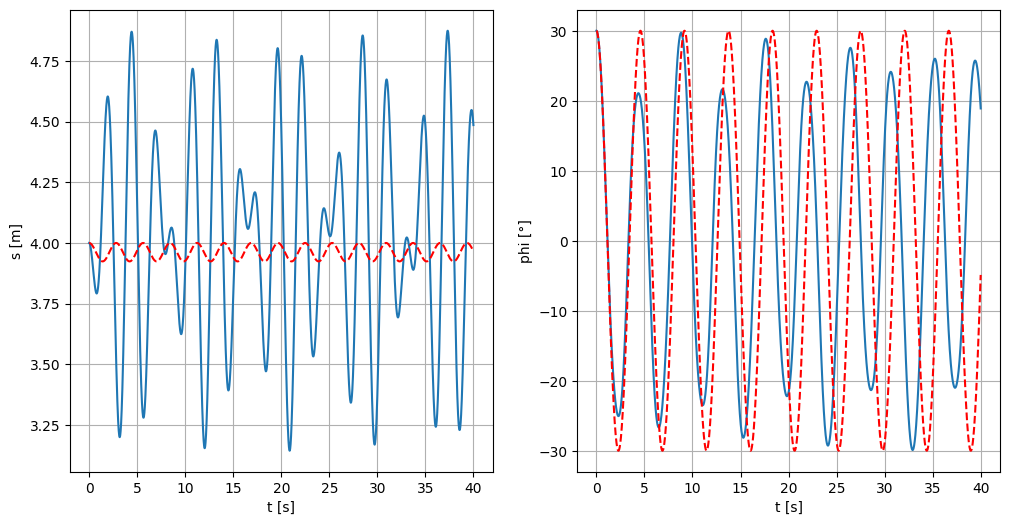

In [58]:
# 
plt.figure(figsize=(12, 6))

plt.subplot(1,2,1)
plt.plot(t, s_nl)
plt.plot(t, s_l, 'r--')
plt.ylabel('s [m]')
plt.xlabel('t [s]')
plt.grid()

plt.subplot(1,2,2)
plt.plot(t, phi_nl)
plt.plot(t, phi_l, 'r--')
plt.ylabel('phi [°]')
plt.xlabel('t [s]')
plt.grid()